# 03 - Market-Stress Forecasting Model (Decision Tree / Random Forest / XGBoost)

Runs the full pipeline for the **market_stress** target end-to-end by calling `src.pipeline.run_target('market_stress', cfg)` -- the exact same function used to generate everything under `results/` and `data/predictions/`. Re-running this notebook regenerates those files from scratch (deterministic given the fixed `random_state`).

Pipeline: cleaned FRED-MD panel -> engineered features -> label -> horizon alignment -> `TimeSeriesSplit` hyperparameter search (imbalance-aware) -> rolling-window walk-forward OOS backtest -> metrics / confusion matrices / XGBoost feature attribution.

In [1]:
import sys
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from pipeline import load_config, run_target

cfg = load_config()

## Run the pipeline

This performs the CV hyperparameter search AND the full rolling-window walk-forward backtest for Decision Tree, Random Forest, and XGBoost. It can take several minutes.

In [2]:
result = run_target('market_stress', cfg, save_outputs=True)
result['metrics_df'].round(4)

2026-09-06 08:12:37,587 INFO ================================================================================


2026-09-06 08:12:37,589 INFO RUNNING PIPELINE for target=market_stress


2026-09-06 08:12:37,589 INFO ================================================================================


2026-09-06 08:12:37,665 INFO remove_null_rows(max_null=6): dropped 1071/1869 rows (date range kept: 1960-01-01 to 2026-07-01)


2026-09-06 08:12:37,668 INFO remove_null_features(max_null=10): dropped 7/110 columns: ['CLAIMSx', 'CMRMTSPLx', 'AMBSL', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUSx']


...

2026-09-06 08:13:16,539 INFO Rolling backtest: model=DT, 234 OOS steps, rolling_window=150, OOS starts 2007-01-01


2026-09-06 08:13:29,008 INFO Rolling backtest: model=RF, 234 OOS steps, rolling_window=150, OOS starts 2007-01-01


2026-09-06 08:15:53,065 INFO Rolling backtest: model=XGB, 234 OOS steps, rolling_window=150, OOS starts 2007-01-01


2026-09-06 08:23:16,866 INFO Rolling-OOS metrics for target=market_stress:
                       DT      RF     XGB
Accuracy           0.9487  0.9573  0.9701
Balanced Accuracy  0.8484  0.7598  0.8598
Precision          0.5789  0.7273  0.7857
Recall             0.7333  0.5333  0.7333
F1                 0.6471  0.6154  0.7586
MCC                0.6249  0.6013  0.7432
ROC-AUC            0.8484  0.8945  0.8916


,DT,RF,XGB
Accuracy,0.9487,0.9573,0.9701
Balanced Accuracy,0.8484,0.7598,0.8598
Precision,0.5789,0.7273,0.7857
Recall,0.7333,0.5333,0.7333
F1,0.6471,0.6154,0.7586
MCC,0.6249,0.6013,0.7432
ROC-AUC,0.8484,0.8945,0.8916


## Best hyperparameters selected (TimeSeriesSplit CV, imbalance-aware)

In [3]:
pd.DataFrame(result['best_params'])

,DT,RF,XGB
max_depth,3.0,5.0,5.0
min_samples_split,2.0,NaN,NaN
min_samples_leaf,1.0,1.0,NaN
n_estimators,NaN,400.0,400.0
learning_rate,NaN,NaN,0.1


## Rolling-OOS confusion matrices

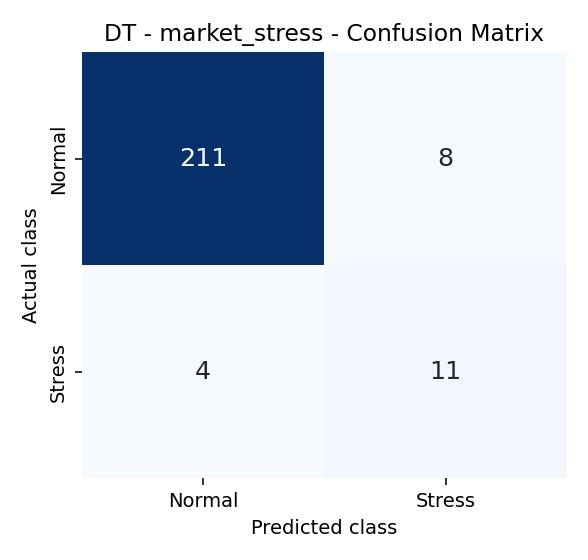

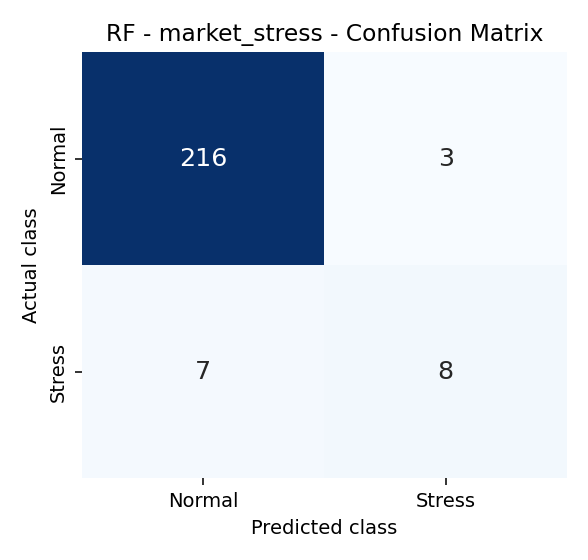

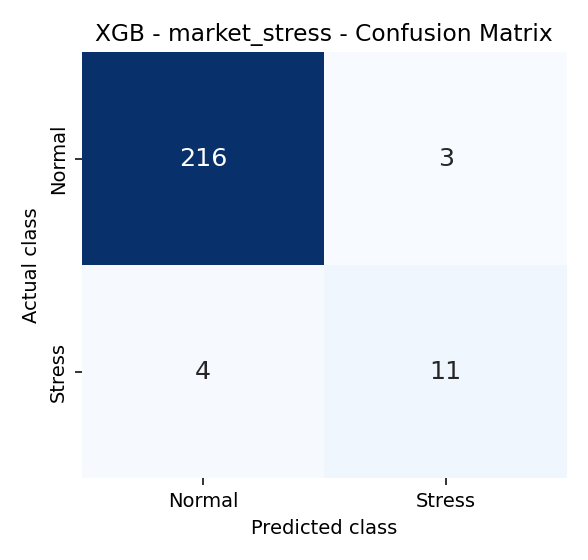

In [4]:
for model in ['DT','RF','XGB']:
    display(Image(filename=f'../results/confusion_matrices/market_stress_{model}_cm.png'))

## Predicted probability vs actual regime, across the full rolling OOS backtest

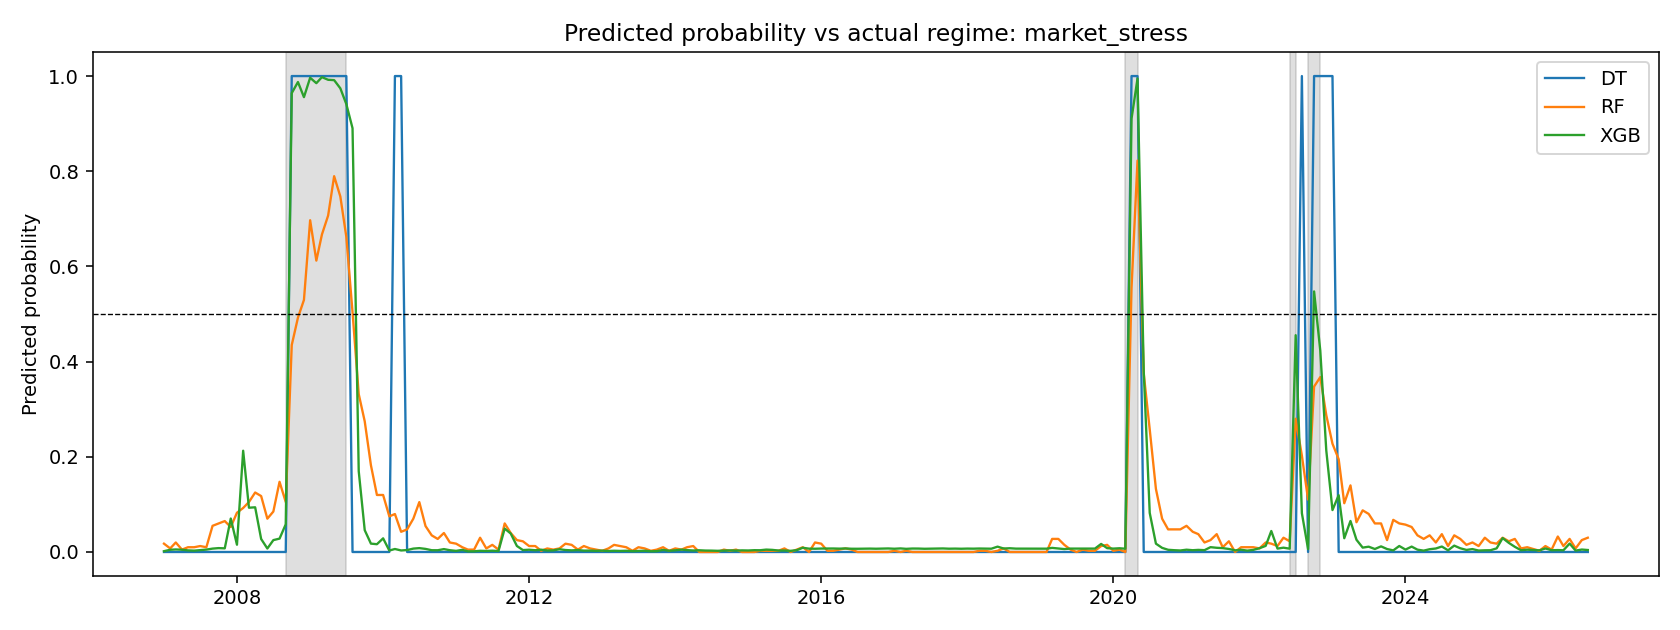

In [5]:
display(Image(filename='../results/figures/market_stress_regime_probabilities.png'))

## XGBoost feature attribution

Aggregated across every rolling-window refit: top individual features, rolled up by macro group, and rolled up by engineered-feature type (lag / spread / momentum / rolling-stat / drawdown / volatility).

In [6]:
fi = pd.read_csv('../results/feature_importance_market_stress.csv')
fi.head(15)

,Feature,Importance,source_series,group,feat_type
0,SP500__drawdown12,0.053194,SP500,Stock Market,drawdown
1,SP500__mom12,0.044454,SP500,Stock Market,momentum
2,DMANEMP__base,0.034169,DMANEMP,Labor Market,base
3,IPMANSICS__mom3,0.029989,IPMANSICS,Output and Income,momentum
4,T1YFFM__rollstd24,0.027114,T1YFFM,Interest and Exchange Rates,rolling_stat
5,TB3SMFFM__lag12,0.026026,TB3SMFFM,Interest and Exchange Rates,lag
6,IPFPNSS__mom3,0.022704,IPFPNSS,Output and Income,momentum
7,PAYEMS__base,0.022650,PAYEMS,Labor Market,base
8,USFIRE__base,0.020782,USFIRE,Labor Market,base
9,CPIMEDSL__mom6,0.016558,CPIMEDSL,Prices,momentum


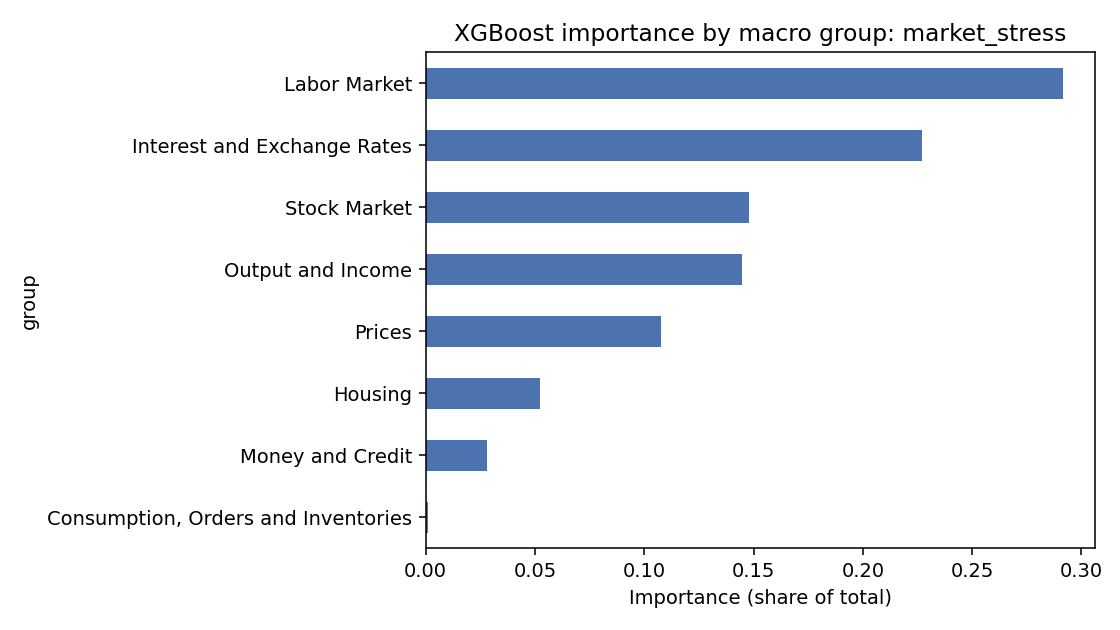

In [7]:
display(Image(filename='../results/figures/market_stress_importance_by_group.png'))

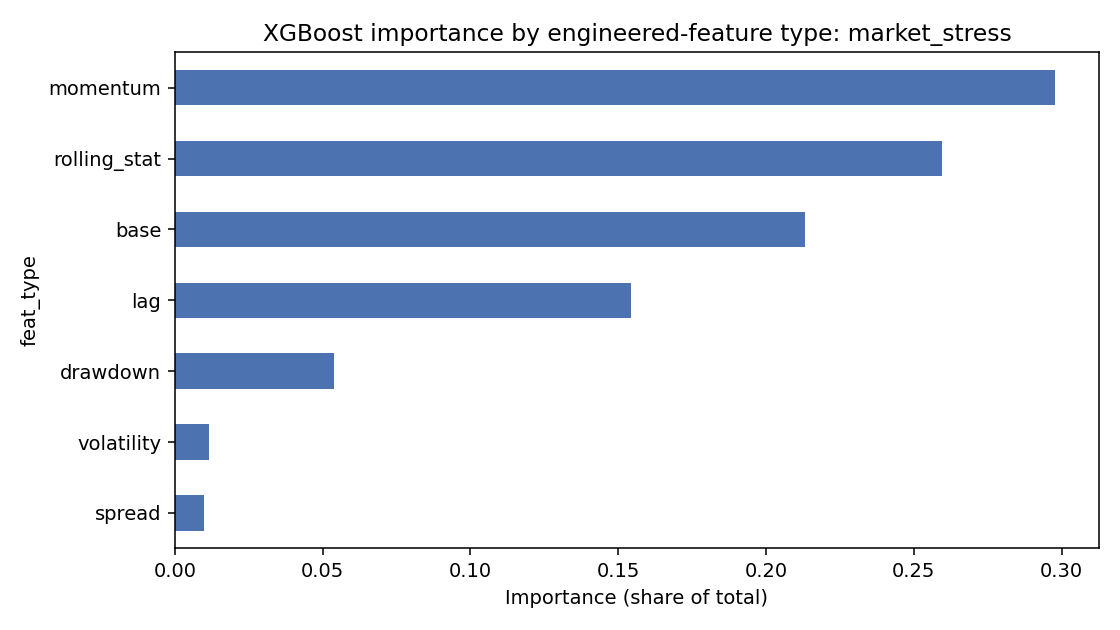

In [8]:
display(Image(filename='../results/figures/market_stress_importance_by_type.png'))